In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as tkr

from DDPM import LinearNoiseScheduler
from DiT_model import DiT
from VAE import VAE

KeyboardInterrupt: 

In [5]:
import pandas as pd
import numpy as np
import os

from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

In [6]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

In [7]:
dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/Lid_Driven_domain", meta = "Lid_Driven")
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(
    device = device, 
    freeze = False, 
    scaling_factor = config["VAE"]["scaling_factor"], 
    path = f"{ROOT}/pretrained/sd-vae-ft-mse"
    ).to(device)
# use path = `stabilityai/sd-vae-ft-mse` for pulling weights from the internet

In [12]:
print(f"{sum(p.numel() for p in vae.parameters()):,}")

83,653,863


In [ ]:
# optimizer = torch.optim.Adam(vae.parameters(),
#     lr = 1e-5
# )

In [ ]:
# num_epochs = 3

# vae.train()

# for epoch in range(num_epochs):
#     total_loss = 0.0
#     for step, (images, numbers, mask) in enumerate(dataloader):
#         images = images.to(device)
#         optimizer.zero_grad()
#         reconstructed, mu, logvar = vae(images)

#         sq = (reconstructed - images).pow(2)   
        
#         mask = mask.float().unsqueeze(1).to(device)                     # [B, 1, 256, 256]
#         sq = sq * mask
#         loss = sq.sum() / mask.sum()

#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#         if step == 9:
#             break

#     print(
#         f"Epoch {epoch + 1} finished, "
#         f"Average Loss: {total_loss / (step + 1):.6f}"
#     )

Epoch 1 finished, Average Loss: 0.613121
Epoch 2 finished, Average Loss: 0.625396
Epoch 3 finished, Average Loss: 0.299067


In [ ]:
# # pick one actual training example
# images, numbers, mask = next(iter(dataloader))
# true_number = numbers[0].item()      # already normalized, matches training distribution

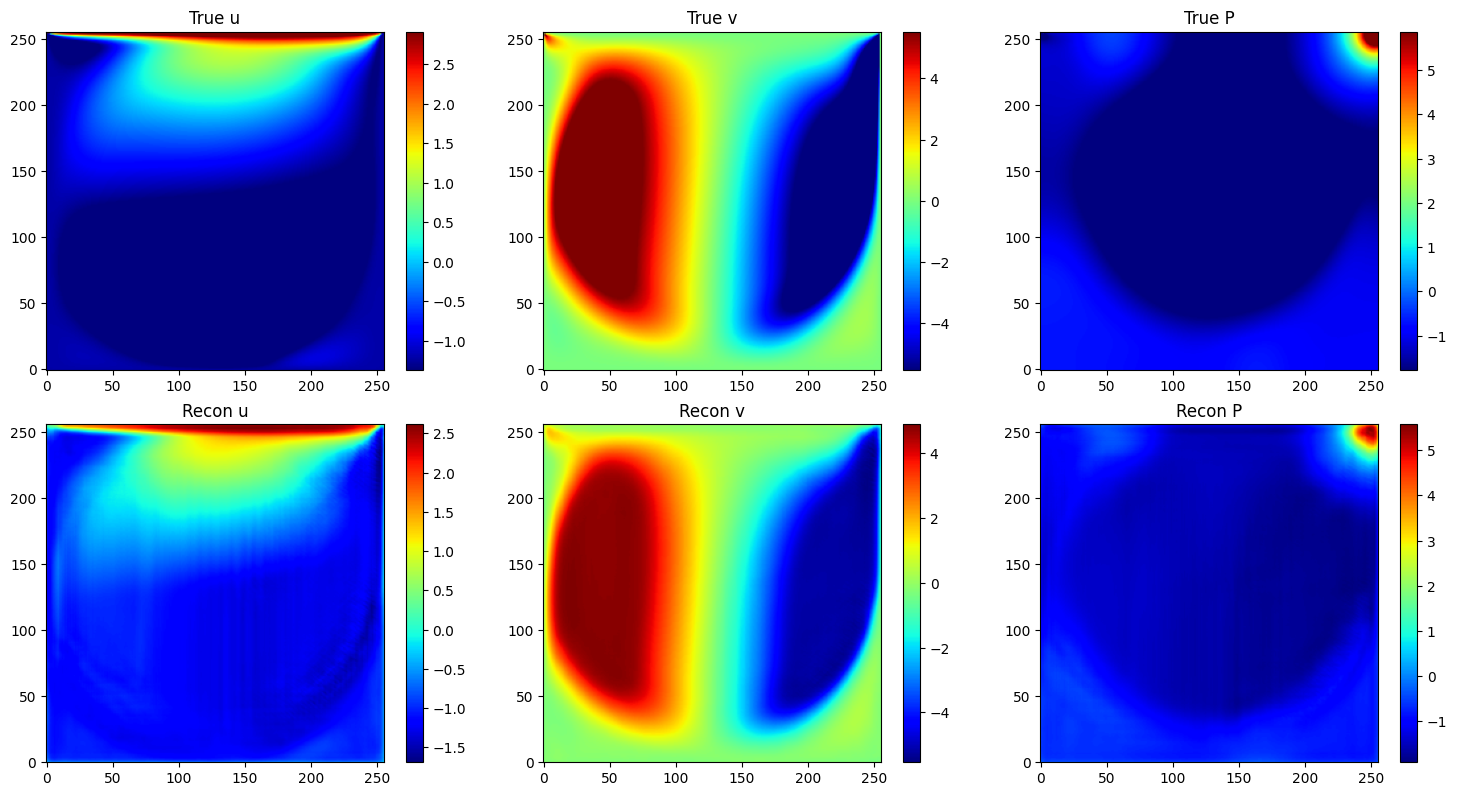

In [ ]:
# with torch.no_grad():
#     mu, logvar = vae.encode(images.to(device))
#     recon = vae.decode(mu)  

# idx = 0
# true_np  = images[idx].detach().cpu().numpy()   
# recon_np = recon[idx].detach().cpu().numpy()    

# channel_names = ["u", "v", "P"]

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# for i, name in enumerate(channel_names):
#     vmin_true = true_np[i].min()
#     vmax_true = true_np[i].max()

#     vmin_recon = recon_np[i].min()
#     vmax_recon = recon_np[i].max()

#     a = axes[0, i].imshow(true_np[i], cmap="jet", vmin=vmin_true, vmax=vmax_true, origin = "lower")
#     axes[0, i].set_title(f"True {name}")
#     fig.colorbar(a, ax=axes[0, i])

#     b = axes[1, i].imshow(recon_np[i], cmap="jet", vmin=vmin_recon, vmax=vmax_recon, origin = "lower")
#     axes[1, i].set_title(f"Recon {name}")
#     fig.colorbar(b, ax=axes[1, i])

# plt.tight_layout()
# plt.show()

In [ ]:
# num_epochs = 3

# vae.train()

# for epoch in range(num_epochs):
#     total_loss = 0.0
#     for step, (images, numbers, mask) in enumerate(dataloader):
#         images = images.to(device)
#         optimizer.zero_grad()
#         reconstructed, mu, logvar = vae(images)
#         loss = torch.nn.functional.mse_loss(reconstructed,images)


#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#         if step == 9:
#             break

#     print(
#         f"Epoch {epoch + 1} finished, "
#         f"Average Loss: {total_loss / (step + 1):.6f}"
#     )

Epoch 1 finished, Average Loss: 0.070328
Epoch 2 finished, Average Loss: 0.054704
Epoch 3 finished, Average Loss: 0.044765


In [ ]:
# images, numbers, mask = next(iter(dataloader))
# true_number = numbers[0].item()      

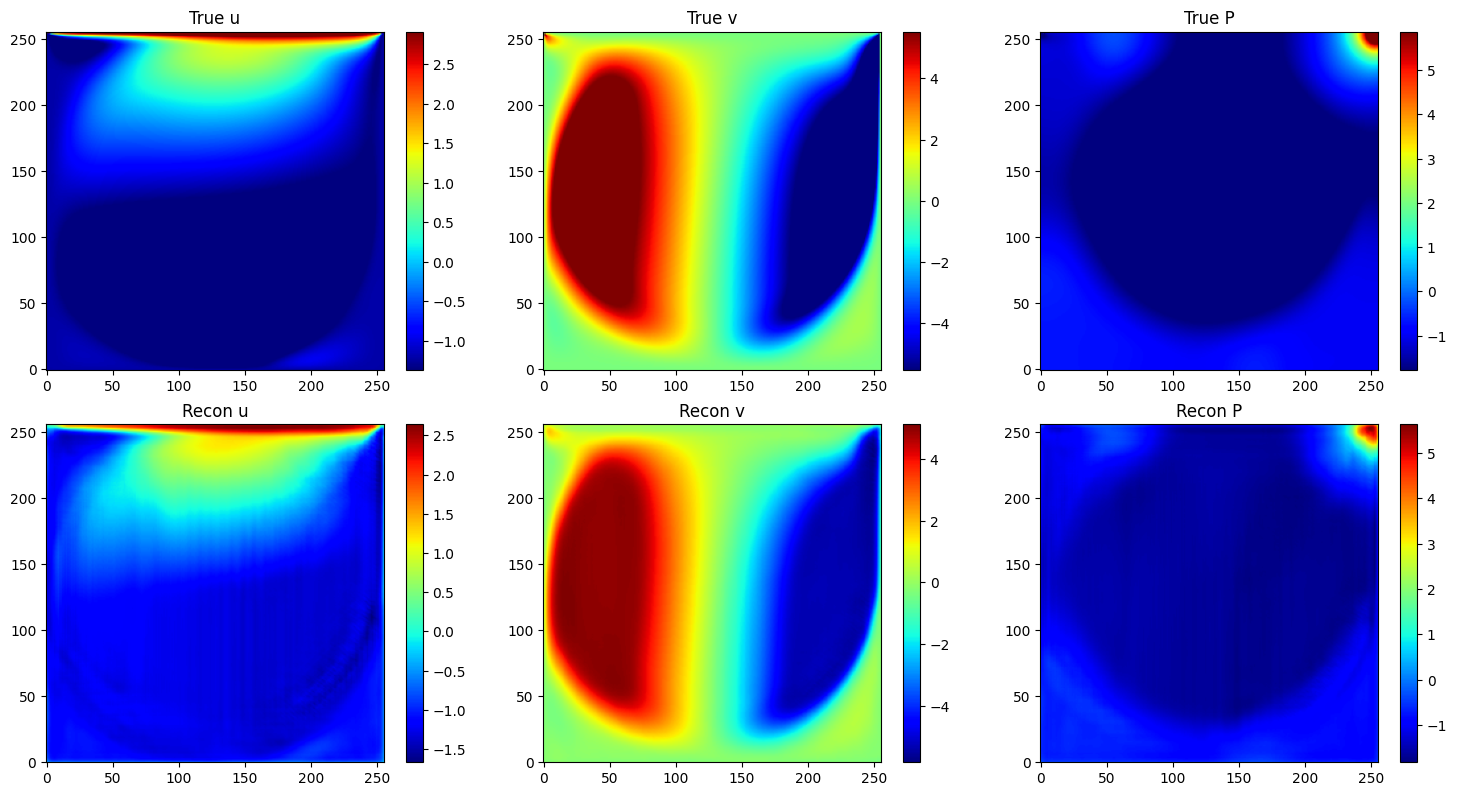

In [ ]:
# with torch.no_grad():
#     mu, logvar = vae.encode(images.to(device))
#     recon = vae.decode(mu)  

# idx = 0
# true_np  = images[idx].detach().cpu().numpy()   
# recon_np = recon[idx].detach().cpu().numpy()    

# channel_names = ["u", "v", "P"]

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# for i, name in enumerate(channel_names):
#     vmin_true = true_np[i].min()
#     vmax_true = true_np[i].max()

#     vmin_recon = recon_np[i].min()
#     vmax_recon = recon_np[i].max()

#     a = axes[0, i].imshow(true_np[i], cmap="jet", vmin=vmin_true, vmax=vmax_true, origin = "lower")
#     axes[0, i].set_title(f"True {name}")
#     fig.colorbar(a, ax=axes[0, i])

#     b = axes[1, i].imshow(recon_np[i], cmap="jet", vmin=vmin_recon, vmax=vmax_recon, origin = "lower")
#     axes[1, i].set_title(f"Recon {name}")
#     fig.colorbar(b, ax=axes[1, i])

# plt.tight_layout()
# plt.show()

In [10]:
kl_weight = 1e-6   

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr = 1e-5
)

num_epochs = 3

vae.train()

for epoch in range(num_epochs):
    total_loss = 0.0
    for step, (images, numbers, mask) in enumerate(dataloader):
        images = images.to(device)
        optimizer.zero_grad()

        reconstructed, mu, logvar = vae(images)

        sq = (reconstructed - images).pow(2)
        mask_ = mask.float().unsqueeze(1).to(device)
        sq = sq * mask_
        recon_loss = sq.sum() / mask_.sum()

        kl_loss = 0.5 * torch.sum(logvar.exp() + mu.pow(2) -1 - logvar)
        kl_loss = kl_loss / mu.shape[0]     # average over batch size

        loss = recon_loss + kl_weight * kl_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # if step == 9:
        #     break

    print(
        f"Epoch {epoch + 1} finished, "
        f"Average Loss: {total_loss / (step + 1):.6f}"
    )

: 

In [ ]:
images, numbers, mask = next(iter(dataloader))
true_number = numbers[0].item()      

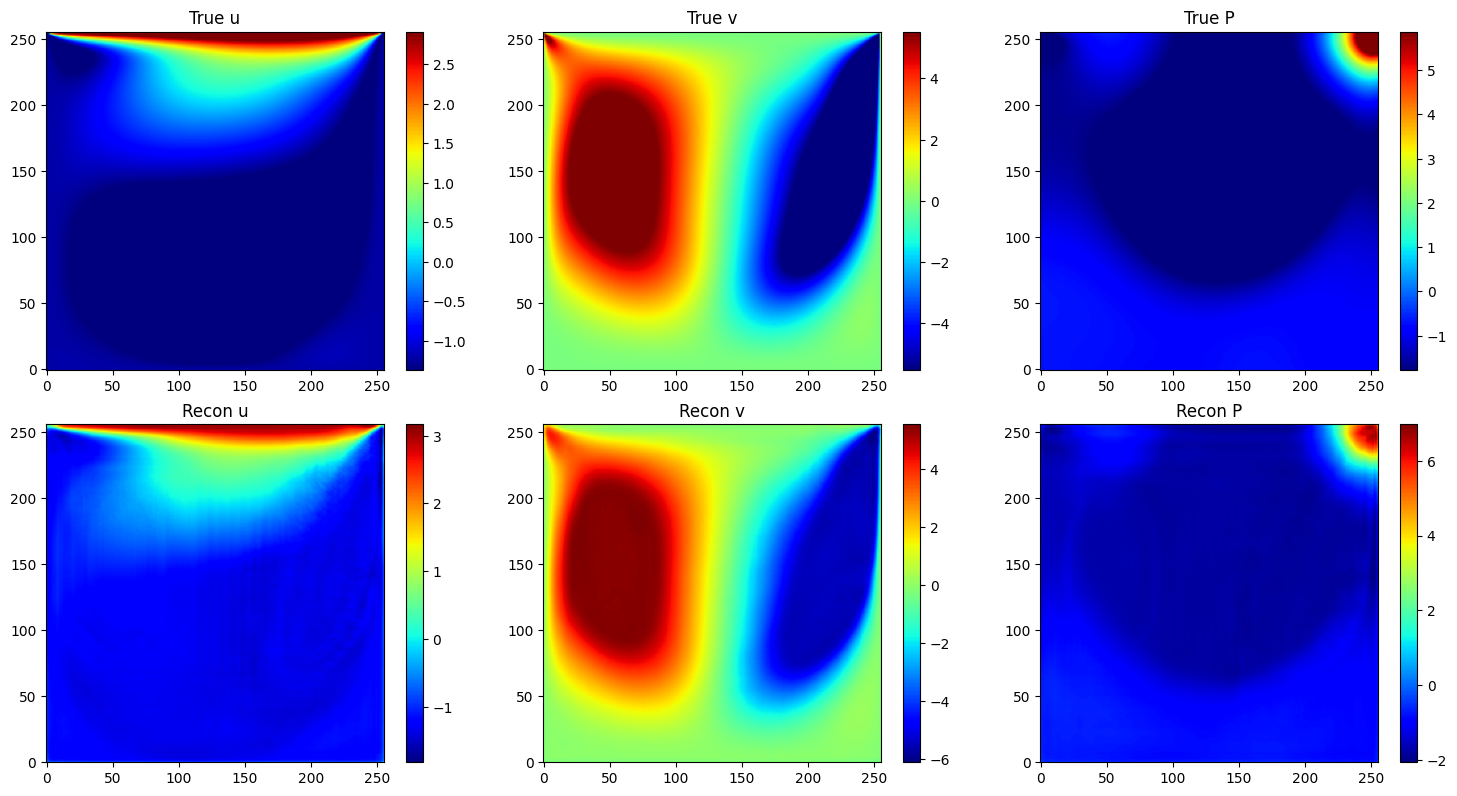

In [22]:
with torch.no_grad():
    mu, logvar = vae.encode(images.to(device))
    recon = vae.decode(mu)  

idx = 0
true_np  = images[idx].detach().cpu().numpy()   
recon_np = recon[idx].detach().cpu().numpy()    

channel_names = ["u", "v", "P"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, name in enumerate(channel_names):
    vmin_true = true_np[i].min()
    vmax_true = true_np[i].max()

    vmin_recon = recon_np[i].min()
    vmax_recon = recon_np[i].max()

    a = axes[0, i].imshow(true_np[i], cmap="jet", vmin=vmin_true, vmax=vmax_true, origin = "lower")
    axes[0, i].set_title(f"True {name}")
    fig.colorbar(a, ax=axes[0, i])

    b = axes[1, i].imshow(recon_np[i], cmap="jet", vmin=vmin_recon, vmax=vmax_recon, origin = "lower")
    axes[1, i].set_title(f"Recon {name}")
    fig.colorbar(b, ax=axes[1, i])

plt.tight_layout()
plt.show()